# EuroSAT Classifier Project

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [4]:
# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

Using device: cpu
PyTorch: 2.11.0+cpu
torchvision: 0.26.0+cpu


### Defining preprocessing transforms

In [5]:
# ImageNet normalization stats. These are required because ResNet18 was trained with these initially
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ResNet expects 224x224 input. But our EuroSAT tiles are 64x64, so we upscale a little.
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),  # doing data augmentation
    transforms.RandomVerticalFlip(),    # knowing that satellite imagery is rotation invariant
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### Downloading our EuroSAT dataset 

In [6]:
# torchvision.datasets.EuroSAT auto downloads
print("Downloading EuroSAT (~90 MB)...")
full_dataset = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=eval_transform  # we will override per split below later
)

print(f"Total images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Number of classes: {len(full_dataset.classes)}")

100%|█████████████████████████████████████████████████████████████████████████████| 94.3M/94.3M [00:01<00:00, 51.7MB/s]


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


### Train / validation / test splits

In [9]:
# Keeping 70% training / 15% validation / 15% testing split
total = len(full_dataset)
train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Here above, random_split function shares the same transform. Overrides training set to use augmentation
# But this requires a small wrapper as random_split returns subset objects, so here it goes:

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset.dataset.samples[self.subset.indices[idx]]
        from PIL import Image
        img = Image.open(img).convert("RGB")
        return self.transform(img), label

train_set = TransformedSubset(train_set, train_transform)
val_set = TransformedSubset(val_set, eval_transform)
test_set = TransformedSubset(test_set, eval_transform)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train: 18900, Val: 4050, Test: 4050


### Visualizing a few images for check up

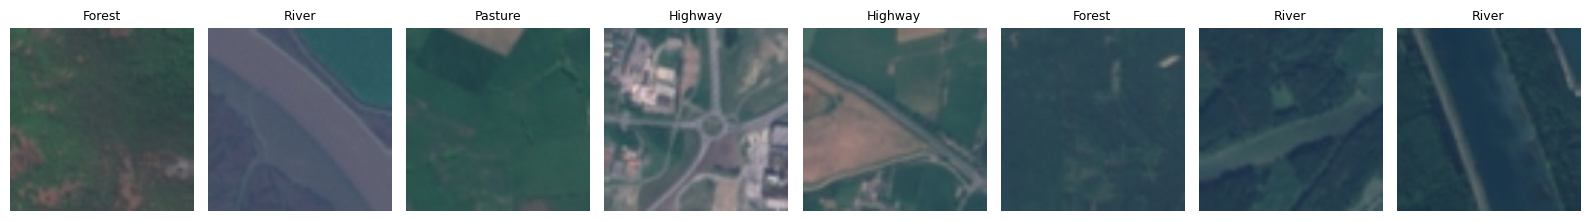

In [10]:
# Seeing 8 images with labels from 1 batch
def imshow_batch(loader, classes, n=8):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    for i in range(n):
        img = images[i].numpy().transpose(1, 2, 0)
        # Denormalize for our display
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(classes[labels[i]], fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader, full_dataset.classes, n=8)

Looks cool, let's proceed further!

### Loading pretrained ResNet18 and modifying for transfer learning

In [11]:
# Loading ResNet18 with pretrained ImageNet weights:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freezing all the pretrained layers:
for param in model.parameters():
    param.requires_grad = False

# Replacing the final fully connected layer:
## Original: fc(512 -> 1000) for ImageNet's 1000 classes
## New: fc(512 -> 10) for our EuroSAT dataset's 10 classes
NUM_CLASSES = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Moving to device:
model = model.to(DEVICE)

# Verifying that only the new layer is trainable:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\FG TECH/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:01<00:00, 42.4MB/s]


Trainable params: 5,130 / 11,181,642 (0.05%)


### Setting up loss function (Binary cross entropy) and optimizer (Adam)

In [12]:
criterion = nn.CrossEntropyLoss()
# Making sure that Adam only optimizes the trainable parameters (the new fc layer) and not prior ones.
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

### Training loop

In [14]:
import time

EPOCHS = 2 # Keeping 2 to save time, earlier I tried 5, good accuracy but takes 1.5 hours on my CPU.  

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # ............................Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        # Printing progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - "
                  f"loss: {train_loss/(batch_idx+1):.4f} - "
                  f"acc: {100.*train_correct/train_total:.2f}%")

    # ...................................Validating
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    elapsed = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{EPOCHS} ({elapsed:.0f}s) - "
          f"train loss: {train_loss/len(train_loader):.4f}, "
          f"train acc: {100.*train_correct/train_total:.2f}% | "
          f"val loss: {val_loss/len(val_loader):.4f}, "
          f"val acc: {100.*val_correct/val_total:.2f}%\n")

print("Training complete!")

  Batch 50/591 - loss: 0.3080 - acc: 88.56%
  Batch 100/591 - loss: 0.3173 - acc: 88.91%
  Batch 150/591 - loss: 0.3100 - acc: 89.54%
  Batch 200/591 - loss: 0.3110 - acc: 89.48%
  Batch 250/591 - loss: 0.3116 - acc: 89.51%
  Batch 300/591 - loss: 0.3102 - acc: 89.52%
  Batch 350/591 - loss: 0.3055 - acc: 89.71%
  Batch 400/591 - loss: 0.3045 - acc: 89.80%
  Batch 450/591 - loss: 0.3075 - acc: 89.63%
  Batch 500/591 - loss: 0.3077 - acc: 89.67%
  Batch 550/591 - loss: 0.3060 - acc: 89.76%

Epoch 1/2 (859s) - train loss: 0.3062, train acc: 89.81% | val loss: 0.2411, val acc: 91.41%

  Batch 50/591 - loss: 0.2945 - acc: 89.38%
  Batch 100/591 - loss: 0.3042 - acc: 89.31%
  Batch 150/591 - loss: 0.2938 - acc: 89.83%
  Batch 200/591 - loss: 0.2898 - acc: 90.06%
  Batch 250/591 - loss: 0.2903 - acc: 89.99%
  Batch 300/591 - loss: 0.2875 - acc: 90.01%
  Batch 350/591 - loss: 0.2840 - acc: 90.15%
  Batch 400/591 - loss: 0.2823 - acc: 90.23%
  Batch 450/591 - loss: 0.2796 - acc: 90.35%
  Batch

Validation accuracy being better than training accuracy shows that model actually generalizes quite well. Now, let's see eval on testset

### Evaluation on the test dataset

In [16]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns 

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc*100:.2f}%\n")

print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

Test accuracy: 92.37%

Per-class report:
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.93      0.94       472
              Forest       0.98      0.96      0.97       442
HerbaceousVegetation       0.89      0.95      0.92       458
             Highway       0.90      0.82      0.86       391
          Industrial       0.97      0.94      0.95       378
             Pasture       0.89      0.94      0.92       299
       PermanentCrop       0.89      0.89      0.89       379
         Residential       0.97      0.96      0.96       450
               River       0.83      0.87      0.85       375
             SeaLake       0.95      0.97      0.96       406

            accuracy                           0.92      4050
           macro avg       0.92      0.92      0.92      4050
        weighted avg       0.92      0.92      0.92      4050



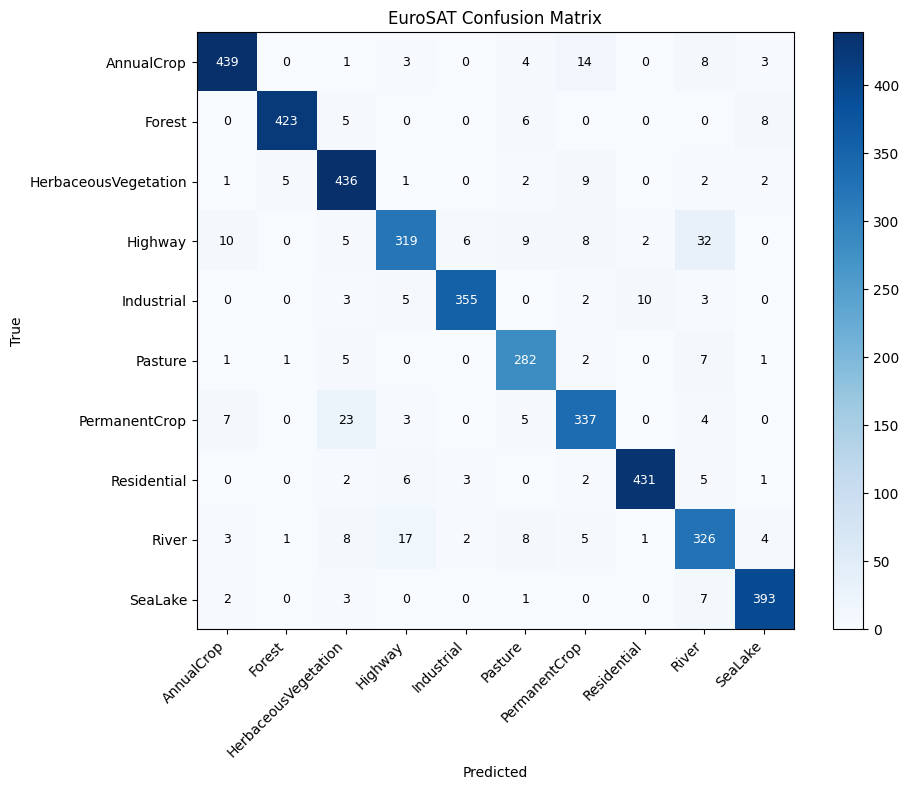

In [18]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(full_dataset.classes)),
    yticks=np.arange(len(full_dataset.classes)),
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes,
    xlabel="Predicted",
    ylabel="True",
    title="EuroSAT Confusion Matrix"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotating cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

Key confusions:
- Some 7% highways cases got confused with rivers, and vice versa. A common mistake, even humans can make this mistake as well if not clearly looked. Can be improved further.
- PermanentCrop got confused with HerbaceousVegetation, again, a common occuring mistake. This can also be further improved.

### Saving trained model

In [20]:
MODEL_PATH = "eurosat_resnet18.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "classes": full_dataset.classes,
    "num_classes": NUM_CLASSES,
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")
print(f"Size: {Path(MODEL_PATH).stat().st_size / 1024 / 1024:.1f} MB")

Model saved to eurosat_resnet18.pth
Size: 42.7 MB


### Running inference on a single random image, just for example.

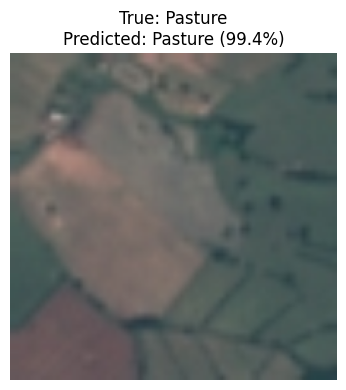

In [22]:
from PIL import Image

# Picking a random test image
import random
idx = random.randint(0, len(test_set) - 1)
img_tensor, true_label = test_set[idx]

# Predicting
model.eval()
with torch.no_grad():
    logits = model(img_tensor.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(logits, dim=1)[0]
    pred = probs.argmax().item()
    confidence = probs[pred].item()

# Showing it now
img = img_tensor.numpy().transpose(1, 2, 0)
img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
img = np.clip(img, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"True: {full_dataset.classes[true_label]}\n"
    f"Predicted: {full_dataset.classes[pred]} ({confidence*100:.1f}%)"
)
plt.tight_layout()
plt.show()

Well, it works great even at low resolution. Glad to have experimented this project.

Pasting screenshot of image above for reference of my comment in case your run-up shows another image: 

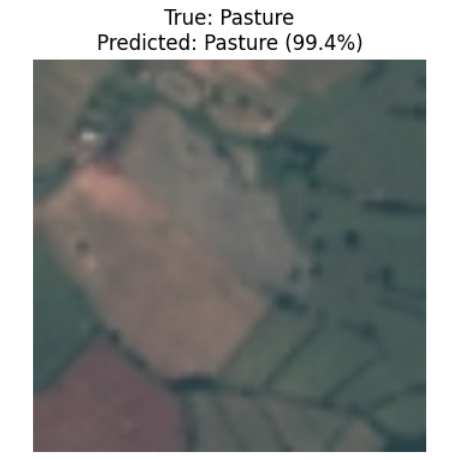
